# Notebook 02 - Telemetry exploration (EDA)
Goal: understand the behaviour of the 4 sensors (volt, rotate, pressure, vibration) before simulating anomalies.

Key questions:
1. What do the distributions look like (Gaussian? skewed? heavy tails)?
2. Are the sensors correlated with each other?
3. Do machines, models or ages behave differently?
4. Is there any daily / weekly / seasonal pattern?
5. Is each series pure noise, or does it have memory (autocorrelation)?
6. Are extreme values isolated, or do several machines show them at the same time? (this decides how we will separate a *grid event* from a *sensor fault* later)

## Step 1 - Imports, configuration and data loading

In [1]:
# ------------------------------------------------------------------
# Step 1: Imports and project configuration.
# We reuse src/config.py (paths + seed) created in Notebook 00.
# ------------------------------------------------------------------
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
from config import RAW, PROCESSED, SEED

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

# Folder where we save figures (they will be reused in the report)
FIG = ROOT / "docs" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

def savefig(name):
    """Save the current matplotlib figure into docs/figures/."""
    plt.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")

# The 4 sensor columns used throughout this notebook
SENSORS = ["volt", "rotate", "pressure", "vibration"]

In [2]:
# ------------------------------------------------------------------
# Step 1b: Load the telemetry (fast path first, CSV as a fallback)
# and merge the machine metadata (model, age).
# Sorting by (machineID, datetime) guarantees that every per-machine
# time operation below (rolling, diff, autocorrelation) is correct.
# ------------------------------------------------------------------
if (PROCESSED / "telemetry.parquet").exists():
    tel = pd.read_parquet(PROCESSED / "telemetry.parquet")
elif (PROCESSED / "telemetry.pkl").exists():
    tel = pd.read_pickle(PROCESSED / "telemetry.pkl")
else:
    tel = pd.read_csv(RAW / "PdM_telemetry.csv", parse_dates=["datetime"])

mach = pd.read_csv(RAW / "PdM_machines.csv")

tel = (tel.merge(mach, on="machineID", how="left")
          .sort_values(["machineID", "datetime"])
          .reset_index(drop=True))

print("Telemetry shape:", tel.shape)
print("Machines:", tel["machineID"].nunique(), "| Models:", sorted(tel["model"].unique()))
display(tel.head())

Telemetry shape: (876100, 8)
Machines: 100 | Models: ['model1', 'model2', 'model3', 'model4']


,datetime,machineID,volt,rotate,pressure,vibration,model,age
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,model3,18
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,model3,18
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,model3,18


## Step 2 - Distribution of each sensor
We look at the histogram and at two shape indicators:
- **skewness** (0 = symmetric)
- **excess kurtosis** (0 = Gaussian tails; positive = heavy tails, i.e. more extreme values than expected)

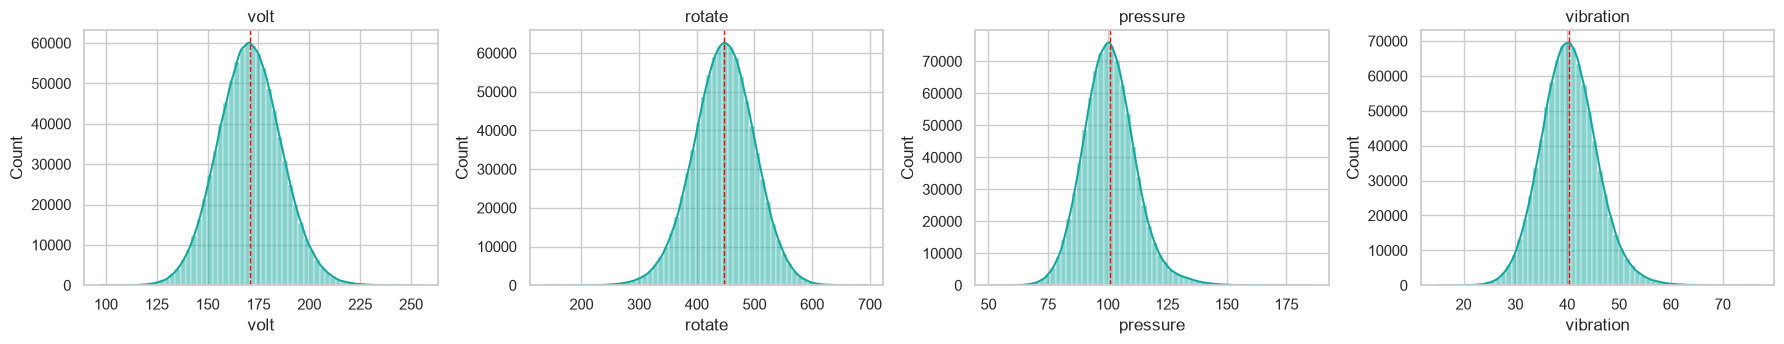

,mean,std,skew,excess_kurtosis
volt,170.778,15.509,0.087,0.115
rotate,446.605,52.674,-0.142,0.203
pressure,100.859,11.049,0.403,0.876
vibration,40.385,5.370,0.249,0.465


In [3]:
# ------------------------------------------------------------------
# Step 2: Histograms of the 4 sensors (all machines pooled).
# The dashed red line is the mean. A bell-shaped histogram suggests
# that the data was generated from a Gaussian-like process.
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for ax, s in zip(axes, SENSORS):
    sns.histplot(tel[s], bins=60, kde=True, ax=ax, color="#13A89E")
    ax.axvline(tel[s].mean(), color="red", ls="--", lw=1)
    ax.set_title(s)
plt.tight_layout()
savefig("02_histograms")
plt.show()

# Shape indicators (pandas computes excess kurtosis: Gaussian = 0)
shape = pd.DataFrame({"mean": tel[SENSORS].mean(),
                      "std": tel[SENSORS].std(),
                      "skew": tel[SENSORS].skew(),
                      "excess_kurtosis": tel[SENSORS].kurt()}).round(3)
display(shape)

In [4]:
# ------------------------------------------------------------------
# Step 2b: How "Gaussian" are the tails?
# For a perfect Gaussian, about 0.27 % of values lie beyond 3 standard
# deviations. A much larger share means heavy tails (natural extreme
# values); a much smaller share means very light tails.
# ------------------------------------------------------------------
rows = []
for s in SENSORS:
    z = (tel[s] - tel[s].mean()) / tel[s].std()
    rows.append({"sensor": s,
                 "share |z|>3 (%)": round((z.abs() > 3).mean() * 100, 3),
                 "expected if Gaussian (%)": 0.27,
                 "min": round(tel[s].min(), 2),
                 "max": round(tel[s].max(), 2)})
display(pd.DataFrame(rows))

,sensor,share |z|>3 (%),expected if Gaussian (%),min,max
0,volt,0.347,0.27,97.33,255.12
1,rotate,0.399,0.27,138.43,695.02
2,pressure,0.783,0.27,51.24,185.95
3,vibration,0.540,0.27,14.88,76.79


## Step 3 - Correlation between sensors
If the sensors are almost uncorrelated, then *physical-consistency rules* (e.g. voltage vs. rotation) will not come from the raw dataset: we will have to create them with the simulated power and current.

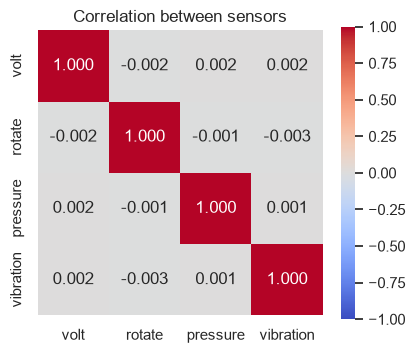

In [5]:
# ------------------------------------------------------------------
# Step 3: Pearson correlation matrix of the 4 sensors.
# Values close to 0 mean the sensors move independently of each other.
# ------------------------------------------------------------------
corr = tel[SENSORS].corr()
plt.figure(figsize=(4.6, 3.8))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation between sensors")
savefig("02_corr_sensors")
plt.show()

## Step 4 - Machine profiles
Do all machines behave the same way, or does each machine have its own baseline? This matters because a per-machine baseline makes anomaly detection more accurate.

,mean,std,min,max
volt_mean,170.78,0.19,170.34,171.27
volt_std,15.51,0.17,15.09,16.02
rotate_mean,446.61,0.81,444.77,448.56
rotate_std,52.67,0.66,51.09,54.92
pressure_mean,100.86,0.31,100.42,101.71
pressure_std,11.04,0.30,10.52,11.90
vibration_mean,40.39,0.12,40.14,40.69
vibration_std,5.37,0.11,5.19,5.64


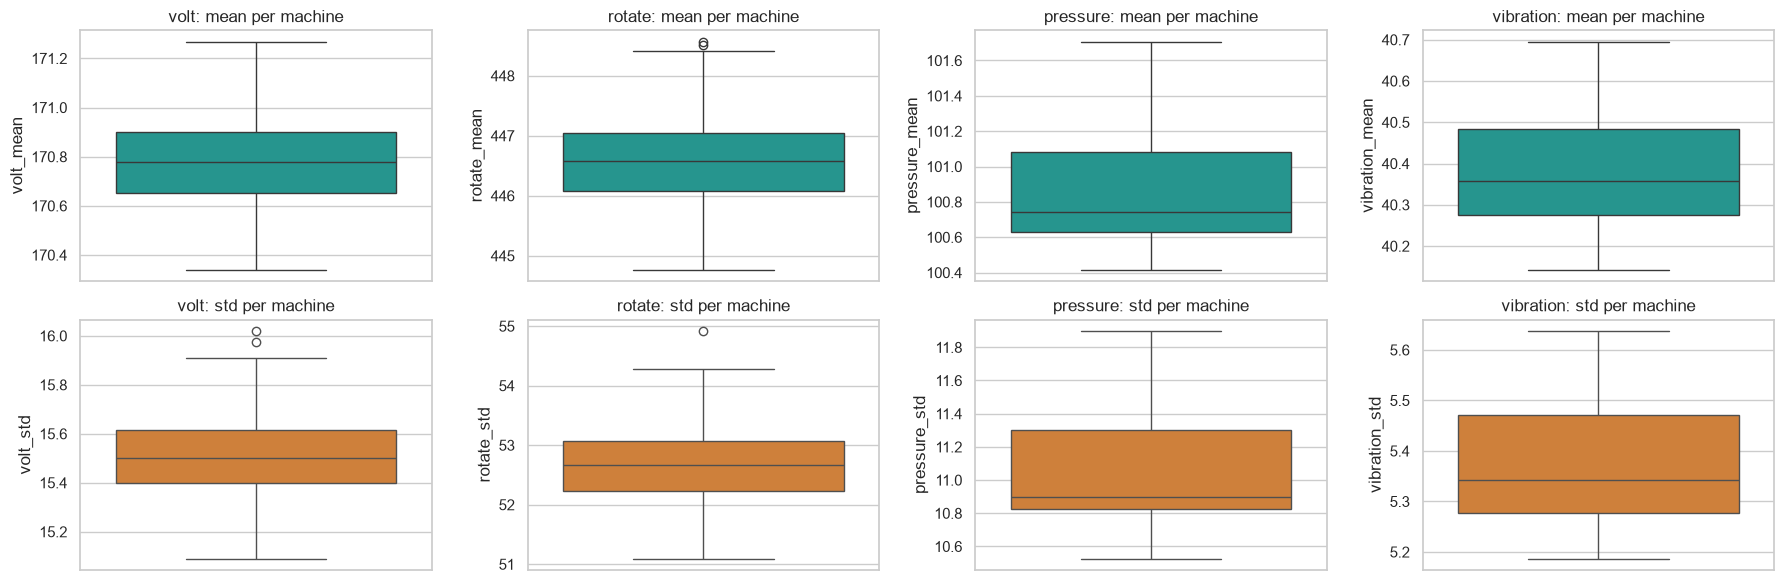

In [6]:
# ------------------------------------------------------------------
# Step 4: Mean and standard deviation of each sensor, per machine.
# We then convert each machine mean into a z-score (how far a machine
# is from the average machine) to spot atypical machines.
# ------------------------------------------------------------------
prof = tel.groupby("machineID")[SENSORS].agg(["mean", "std"])
prof.columns = [f"{a}_{b}" for a, b in prof.columns]   # flatten column names

display(prof.describe().round(2).T[["mean", "std", "min", "max"]])

# Spread of machine means and machine standard deviations (boxplots)
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
for j, s in enumerate(SENSORS):
    sns.boxplot(y=prof[f"{s}_mean"], ax=axes[0, j], color="#13A89E")
    axes[0, j].set_title(f"{s}: mean per machine")
    sns.boxplot(y=prof[f"{s}_std"], ax=axes[1, j], color="#E67E22")
    axes[1, j].set_title(f"{s}: std per machine")
plt.tight_layout()
savefig("02_machine_profiles")
plt.show()

In [7]:
# ------------------------------------------------------------------
# Step 4b: List the most atypical machines (|z| > 2.5 on a mean).
# An empty list means all machines share almost the same baseline.
# ------------------------------------------------------------------
mean_cols = [f"{s}_mean" for s in SENSORS]
zm = (prof[mean_cols] - prof[mean_cols].mean()) / prof[mean_cols].std()
atypical = zm[(zm.abs() > 2.5).any(axis=1)].round(2)
print("Machines with an atypical mean (|z| > 2.5):", len(atypical))
display(atypical)

Machines with an atypical mean (|z| > 2.5): 2


,volt_mean,rotate_mean,pressure_mean,vibration_mean
machineID,,,,
66,2.58,0.84,-1.29,-0.21
98,0.02,-0.66,2.74,0.92


## Step 5 - Differences by machine model and by age

volt         rotate        pressure        vibration      
          mean    std    mean    std     mean    std      mean   std
model                                                               
model1  170.78  15.56  446.37  52.95   101.27  11.46     40.44  5.41
model2  170.72  15.51  446.81  52.53   101.22  11.38     40.39  5.38
model3  170.81  15.49  446.51  52.71   100.67  10.85     40.40  5.36
model4  170.77  15.50  446.71  52.57   100.67  10.86     40.34  5.36


Correlation between machine age and machine mean:


,corr_with_age
volt_mean,-0.055
rotate_mean,-0.063
pressure_mean,0.137
vibration_mean,0.754


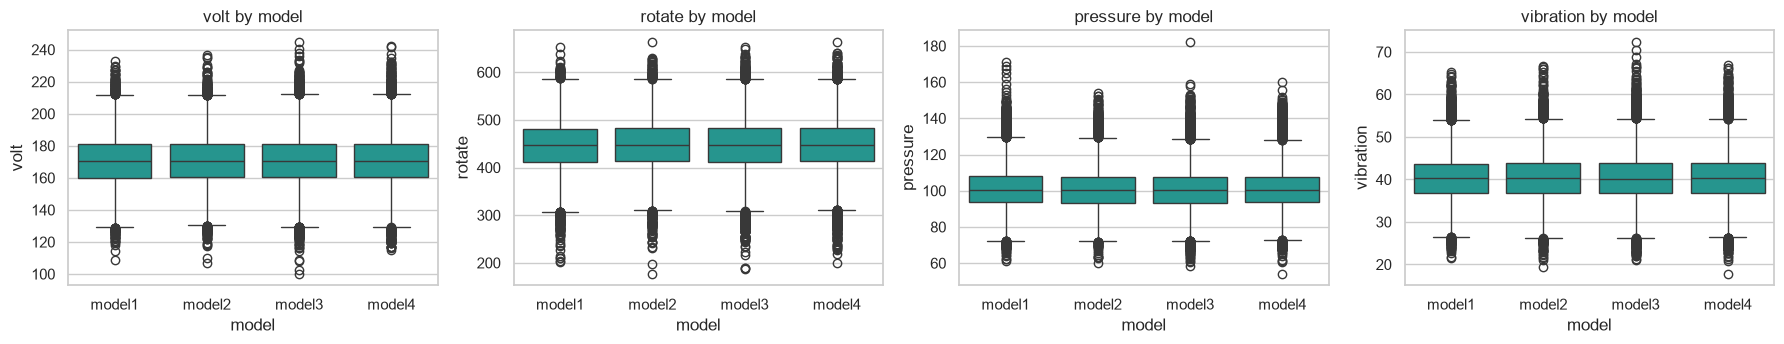

In [8]:
# ------------------------------------------------------------------
# Step 5: Compare the 4 machine models and test the effect of age.
# - groupby("model"): average sensor values per model
# - correlation between age and each machine mean
# If the numbers are very close, model and age have little influence
# on the raw sensors (they may still matter for failures: Notebook 03).
# ------------------------------------------------------------------
display(tel.groupby("model")[SENSORS].agg(["mean", "std"]).round(2))

age_df = prof[mean_cols].join(mach.set_index("machineID")["age"])
print("\nCorrelation between machine age and machine mean:")
display(age_df.corr()["age"].drop("age").round(3).to_frame("corr_with_age"))

fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for ax, s in zip(axes, SENSORS):
    sns.boxplot(data=tel.sample(100000, random_state=SEED), x="model", y=s,
                order=sorted(tel["model"].unique()), ax=ax, color="#13A89E")
    ax.set_title(f"{s} by model")
plt.tight_layout()
savefig("02_by_model")
plt.show()

## Step 6 - Time patterns (hour of day, day of week, month)
Real electrical data has strong daily and seasonal cycles. Here we check whether the synthetic data has any.

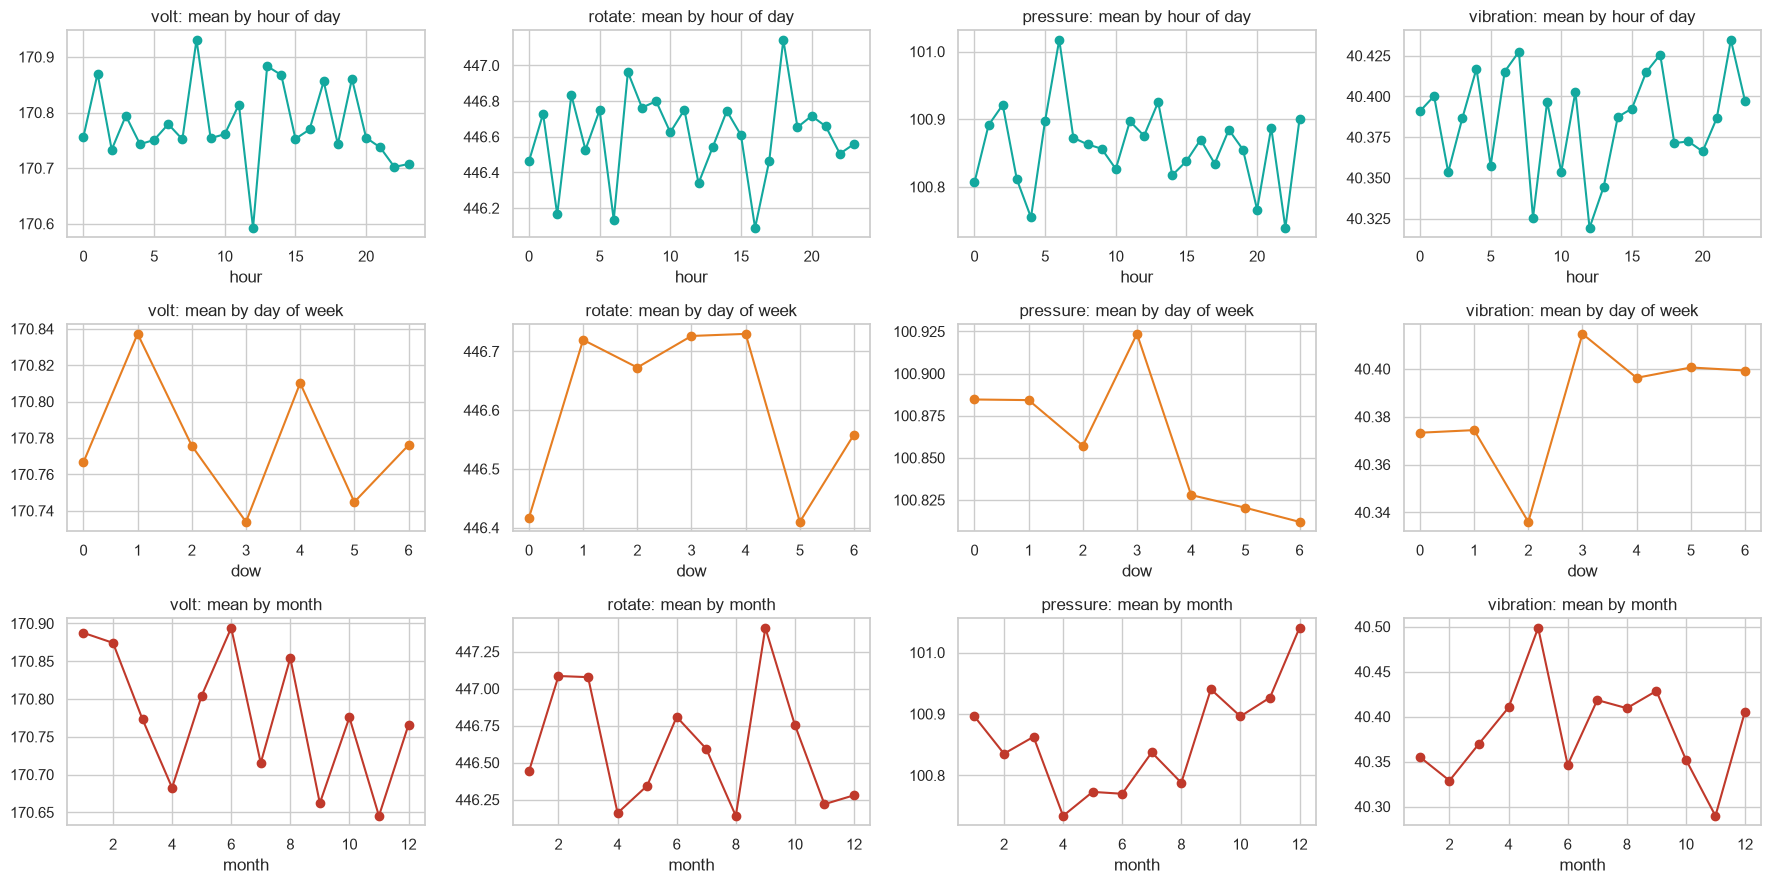

Daily-cycle amplitude / global std (close to 0 = no daily cycle): {'volt': 0.022, 'rotate': 0.02, 'pressure': 0.025, 'vibration': 0.021}


In [9]:
# ------------------------------------------------------------------
# Step 6: Average of each sensor by hour of day, day of week and month.
# Flat curves mean there is NO daily/weekly/seasonal pattern in the
# raw dataset: realistic load profiles must then be added by us
# (the challenge mentions seasonal peaks).
# ------------------------------------------------------------------
tel["hour"] = tel["datetime"].dt.hour
tel["dow"] = tel["datetime"].dt.dayofweek       # 0 = Monday
tel["month"] = tel["datetime"].dt.month

fig, axes = plt.subplots(3, 4, figsize=(18, 9))
for j, s in enumerate(SENSORS):
    tel.groupby("hour")[s].mean().plot(ax=axes[0, j], marker="o", color="#13A89E")
    axes[0, j].set_title(f"{s}: mean by hour of day")
    tel.groupby("dow")[s].mean().plot(ax=axes[1, j], marker="o", color="#E67E22")
    axes[1, j].set_title(f"{s}: mean by day of week")
    tel.groupby("month")[s].mean().plot(ax=axes[2, j], marker="o", color="#C0392B")
    axes[2, j].set_title(f"{s}: mean by month")
plt.tight_layout()
savefig("02_time_patterns")
plt.show()

# Size of the variation of the hourly curve, relative to the global std
amp = {s: float(round((tel.groupby("hour")[s].mean().max() - tel.groupby("hour")[s].mean().min()) / tel[s].std(), 3))
       for s in SENSORS}
print("Daily-cycle amplitude / global std (close to 0 = no daily cycle):", amp)

## Step 7 - A closer look at a few machines
We plot the raw series and a 24-hour rolling mean to see what the data really looks like over time.

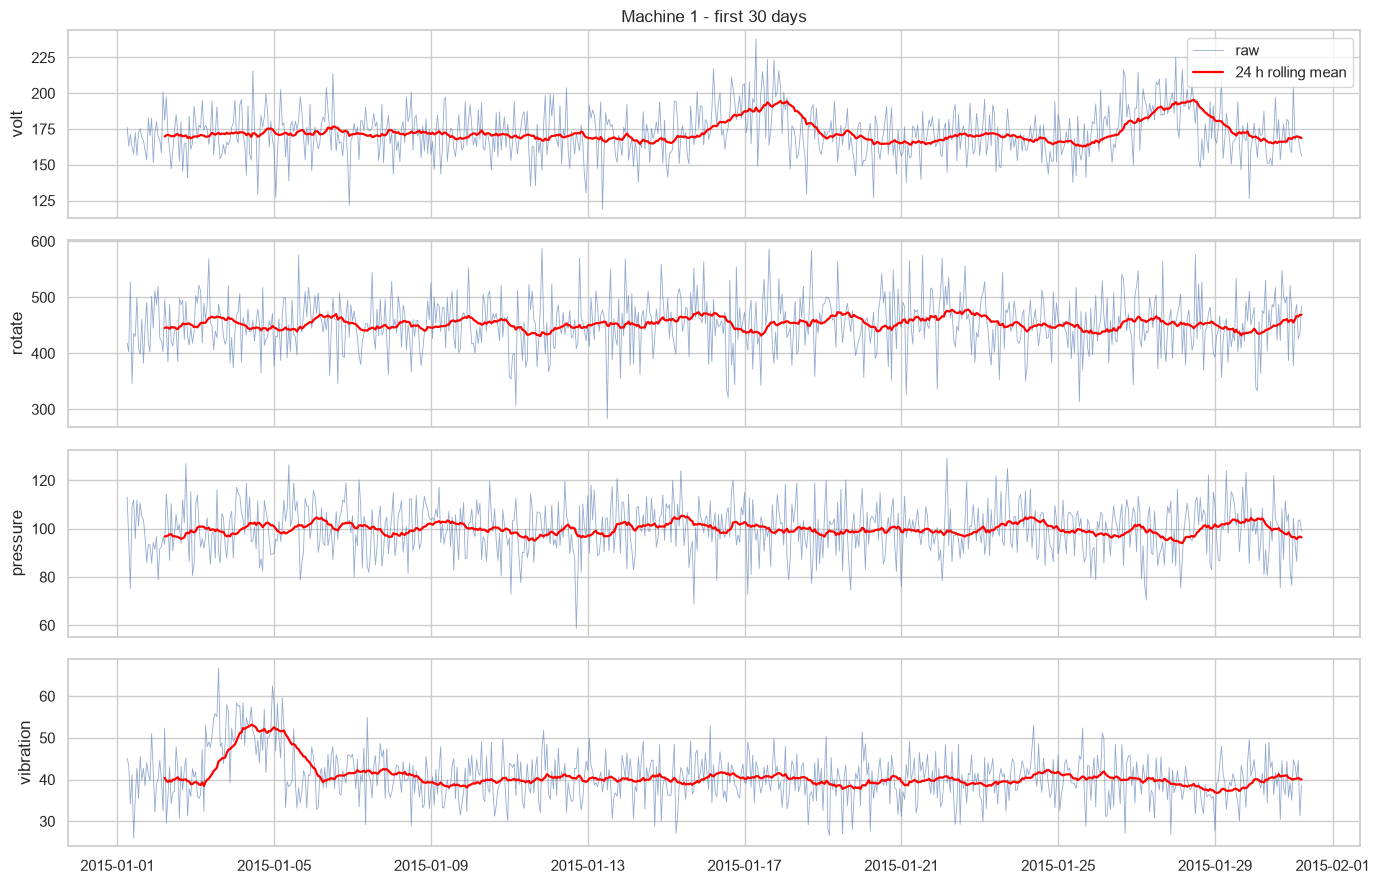

In [10]:
# ------------------------------------------------------------------
# Step 7: Plot the first 30 days of machine 1 (raw + 24 h rolling mean).
# The rolling mean (24 values = 1 day) smooths the noise and reveals
# slow trends. We use only one machine to keep the plot readable.
# ------------------------------------------------------------------
m1 = tel[(tel["machineID"] == 1)].head(24 * 30).set_index("datetime")

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
for ax, s in zip(axes, SENSORS):
    ax.plot(m1.index, m1[s], lw=0.6, alpha=0.6, label="raw")
    ax.plot(m1.index, m1[s].rolling(24).mean(), lw=1.6, color="red", label="24 h rolling mean")
    ax.set_ylabel(s)
axes[0].legend(loc="upper right")
axes[0].set_title("Machine 1 - first 30 days")
plt.tight_layout()
savefig("02_machine1_series")
plt.show()

## Step 8 - Memory of the series (autocorrelation)
Autocorrelation measures how much a value depends on the previous ones. Values near 0 mean the series behaves like **white noise**: every hour is independent of the previous one.

In [11]:
# ------------------------------------------------------------------
# Step 8: Lag-1 (1 hour) and lag-24 (1 day) autocorrelation, computed
# on each machine separately, then averaged over the 100 machines.
# Near 0  -> no memory, no daily rhythm (white-noise-like data).
# Near 1  -> strong persistence (typical of real physical signals).
# ------------------------------------------------------------------
rows = []
for s in SENSORS:
    ac1 = tel.groupby("machineID")[s].apply(lambda x: x.autocorr(lag=1))
    ac24 = tel.groupby("machineID")[s].apply(lambda x: x.autocorr(lag=24))
    rows.append({"sensor": s,
                 "mean autocorr lag 1 h": round(ac1.mean(), 3),
                 "mean autocorr lag 24 h": round(ac24.mean(), 3)})
acf = pd.DataFrame(rows)
display(acf)

,sensor,mean autocorr lag 1 h,mean autocorr lag 24 h
0,volt,0.063,0.031
1,rotate,0.093,0.047
2,pressure,0.174,0.089
3,vibration,0.127,0.065


## Step 9 - Extreme values and simultaneity across machines
**This is the most important step for EnergyMind.** Our trust layer must distinguish a *genuine grid event* (several machines affected at the same time) from a *data-quality problem* (a single machine affected). So we must know what the raw data does naturally: are natural extremes isolated or simultaneous?

In [12]:
# ------------------------------------------------------------------
# Step 9a: Per-machine z-scores.
# Each value is compared with the mean and std of ITS OWN machine,
# so a machine with a slightly different baseline is not penalised.
# We count how many values exceed 3 standard deviations.
# ------------------------------------------------------------------
g = tel.groupby("machineID")
for s in SENSORS:
    tel[f"z_{s}"] = (tel[s] - g[s].transform("mean")) / g[s].transform("std")

ext = pd.DataFrame({s: (tel[f"z_{s}"].abs() > 3).groupby(tel["machineID"]).sum() for s in SENSORS})
print("Number of |z| > 3 values per machine (summary):")
display(ext.describe().round(1))
print("Total extreme values per sensor:", ext.sum().to_dict())

Number of |z| > 3 values per machine (summary):


,volt,rotate,pressure,vibration
count,100.0,100.0,100.0,100.0
mean,30.3,34.6,66.9,46.4
std,5.5,6.3,10.5,10.7
min,19.0,18.0,43.0,30.0
25%,26.0,30.8,61.0,39.0
50%,30.0,34.0,66.0,43.0
75%,33.2,38.0,72.2,53.0
max,48.0,52.0,121.0,90.0


Total extreme values per sensor: {'volt': 3032, 'rotate': 3456, 'pressure': 6693, 'vibration': 4644}


In [13]:
# ------------------------------------------------------------------
# Step 9b: Are natural extremes simultaneous across machines?
# For each timestamp we count how many of the 100 machines have an
# extreme volt value. If the machines were independent, this count
# would be 0 almost always and larger counts would be very rare.
# We compare with the number expected under independence (Poisson).
# ------------------------------------------------------------------
from scipy.stats import poisson

flag = (tel["z_volt"].abs() > 3)
n_extreme_per_time = flag.groupby(tel["datetime"]).sum()

p = flag.mean()                              # probability of an extreme value
lam = p * tel["machineID"].nunique()         # expected extremes per timestamp
obs = n_extreme_per_time.value_counts().sort_index()

cmp_df = pd.DataFrame({"observed timestamps": obs})
cmp_df.index.name = "machines with extreme volt at the same hour"
cmp_df["expected (independent machines)"] = [round(poisson.pmf(k, lam) * len(n_extreme_per_time), 1)
                                              for k in cmp_df.index]
print(f"Extreme-value probability p = {p:.4%} | expected per timestamp = {lam:.3f}")
display(cmp_df)
print("Maximum number of machines with an extreme volt at the same hour:",
      int(n_extreme_per_time.max()))

Extreme-value probability p = 0.3461% | expected per timestamp = 0.346


,observed timestamps,expected (independent machines)
machines with extreme volt at the same hour,,
0,6198,6198.0
1,2147,2145.0
2,368,371.2
3,43,42.8
4,5,3.7


Maximum number of machines with an extreme volt at the same hour: 4


Mean pairwise correlation of volt between machines: 0.0001
Max pairwise correlation: 0.0337 | Min: -0.0315


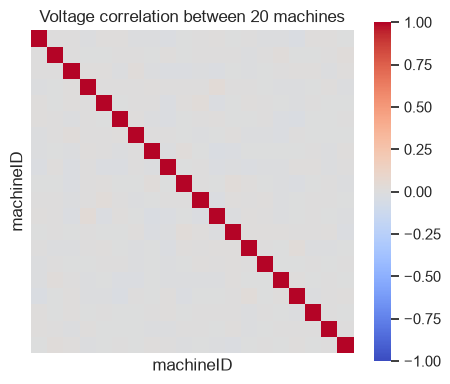

In [14]:
# ------------------------------------------------------------------
# Step 9c: Cross-machine correlation of the voltage.
# We pivot to a (time x machine) table and correlate the machines.
# A mean correlation near 0 means the machines are independent in the
# raw data: NO common grid signal exists, so we will have to create
# genuine grid events ourselves (simultaneous sag/surge/outage).
# ------------------------------------------------------------------
pv = tel.pivot(index="datetime", columns="machineID", values="volt")
sub = pv.iloc[:, :40]                         # 40 machines are enough for the estimate
cm = sub.corr().values
offdiag = cm[~np.eye(cm.shape[0], dtype=bool)]
print(f"Mean pairwise correlation of volt between machines: {offdiag.mean():.4f}")
print(f"Max pairwise correlation: {offdiag.max():.4f} | Min: {offdiag.min():.4f}")

plt.figure(figsize=(5.2, 4.4))
sns.heatmap(sub.iloc[:, :20].corr(), cmap="coolwarm", vmin=-1, vmax=1, square=True,
            xticklabels=False, yticklabels=False)
plt.title("Voltage correlation between 20 machines")
savefig("02_cross_machine_corr")
plt.show()

## Step 10 - Summary and saved outputs

In [15]:
# ------------------------------------------------------------------
# Step 10a: Build a compact summary of the key findings.
# These numbers go straight into the project proposal (data
# exploration section), so we print them in one table.
# ------------------------------------------------------------------
summary = {
    "rows": len(tel),
    "machines": int(tel["machineID"].nunique()),
    "max |corr| between sensors": round(float(corr.where(~np.eye(4, dtype=bool)).abs().max().max()), 3),
    "mean autocorr lag 1 (all sensors)": round(float(acf["mean autocorr lag 1 h"].mean()), 3),
    "mean pairwise corr volt (machines)": round(float(offdiag.mean()), 4),
    "max machines extreme at same hour": int(n_extreme_per_time.max()),
    "atypical machines (|z|>2.5)": int(len(atypical)),
}
display(pd.Series(summary, name="value").to_frame())

,value
rows,876100.0000
machines,100.0000
max |corr| between sensors,0.0030
mean autocorr lag 1 (all sensors),0.1140
mean pairwise corr volt (machines),0.0001
max machines extreme at same hour,4.0000
atypical machines (|z|>2.5),2.0000


In [16]:
# ------------------------------------------------------------------
# Step 10b: Save the outputs of this notebook.
# - machine_profile.csv : per-machine mean/std (baseline for the
#   later notebooks and for the per-node design)
# - telemetry_eda.parquet/pkl : telemetry with model, age and z-scores
# The temporary time columns are kept; they are cheap to recompute.
# ------------------------------------------------------------------
PROCESSED.mkdir(parents=True, exist_ok=True)
prof.round(4).to_csv(PROCESSED / "machine_profile.csv")

try:
    tel.to_parquet(PROCESSED / "telemetry_eda.parquet", index=False)
    saved = "parquet"
except Exception as e:
    tel.to_pickle(PROCESSED / "telemetry_eda.pkl")
    saved = f"pickle (parquet unavailable: {type(e).__name__})"
print("Saved: machine_profile.csv and telemetry_eda as", saved)
print("Figures saved in:", FIG)

Saved: machine_profile.csv and telemetry_eda as parquet
Figures saved in: C:\Users\USER\anaconda_projects\ae0031cb-ad1c-4e8e-b428-a8bce55a9655\docs\figures


## Your observations (fill in after running)
Write 5-8 short sentences in your own words. They go directly into the proposal.

- Distribution of the sensors: ...
- Correlation between sensors: ...
- Differences between machines / models / ages: ...
- Daily / weekly / seasonal pattern: ...
- Autocorrelation (memory of the series): ...
- Natural extremes: isolated or simultaneous? ...
- Consequence for our simulation plan: ...